Model loaded successfully!


Saving person.jpg to person.jpg
Saving parrot.jpeg to parrot (1).jpeg
Saving banana.jpeg to banana (1).jpeg
Saving flight.jpeg to flight (3).jpeg
Saving dog.jpeg to dog (4).jpeg
Saving cat.jpg to cat (4).jpg
Saving starfruit.jpeg to starfruit (5).jpeg
Saving apple.jpg to apple (5).jpg
Total images uploaded: 8


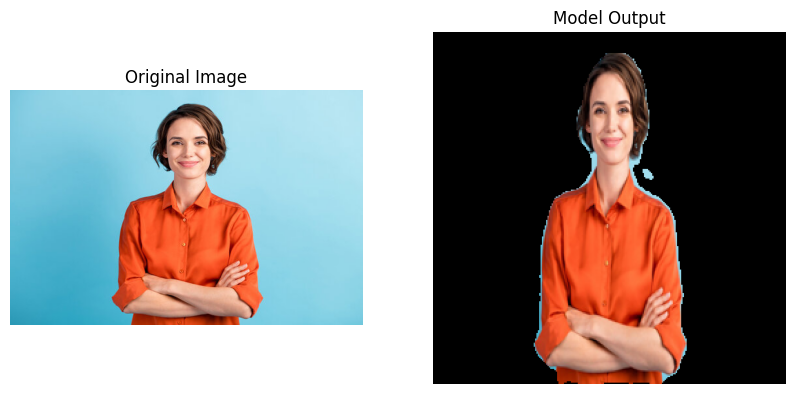

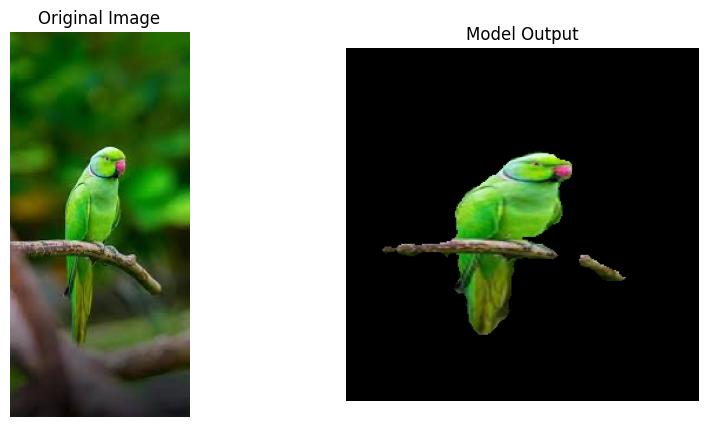

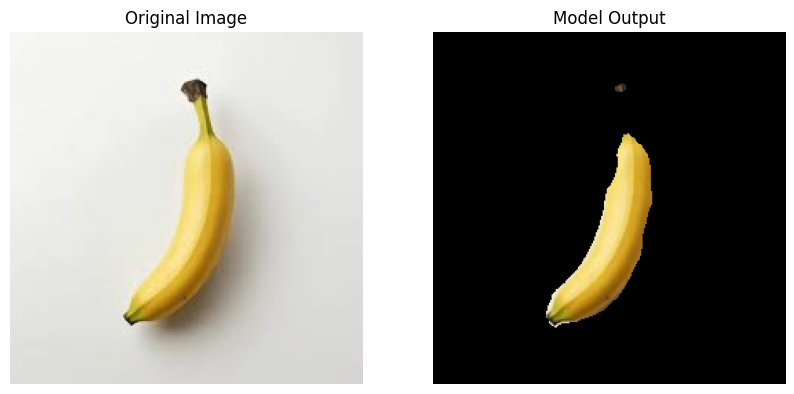

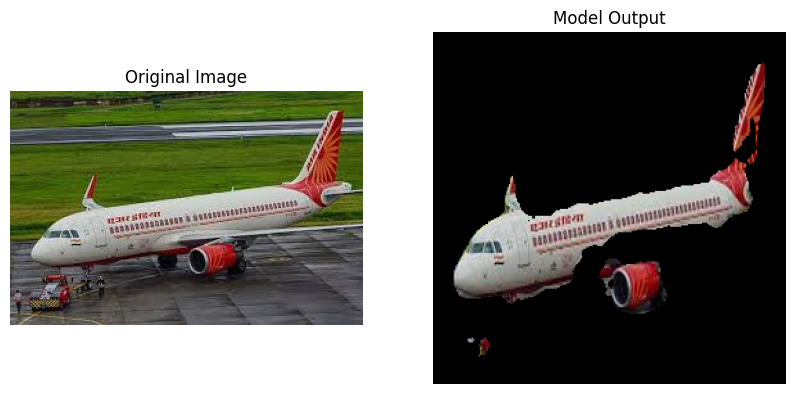

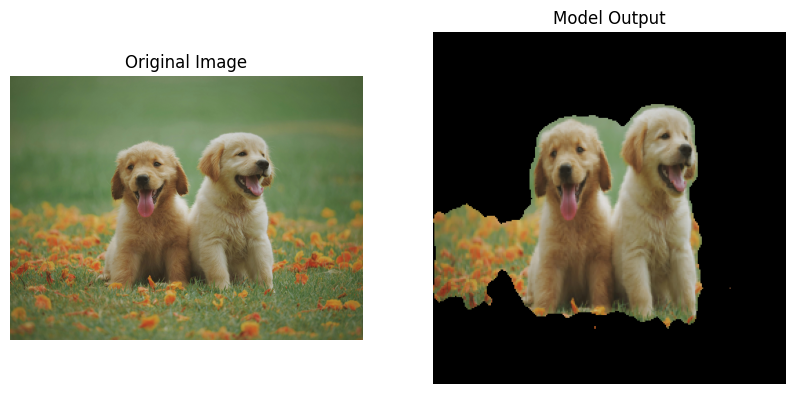

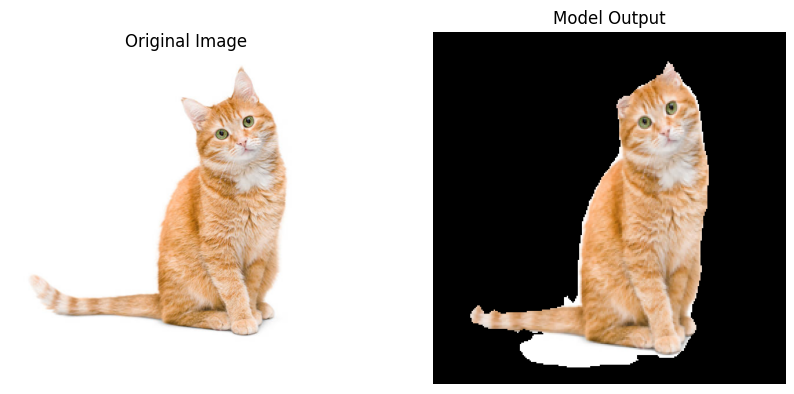

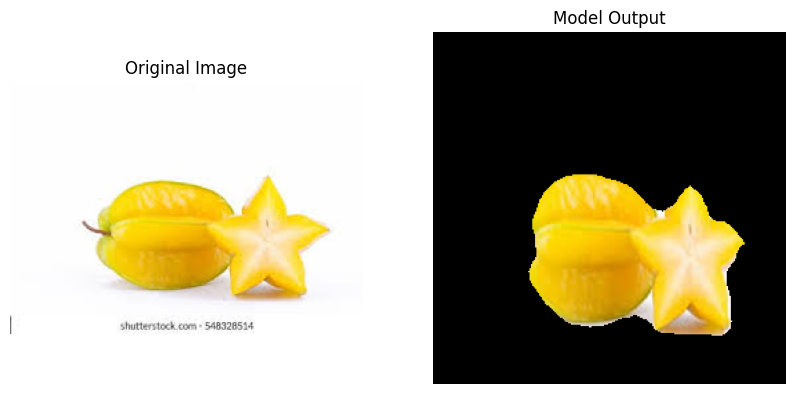

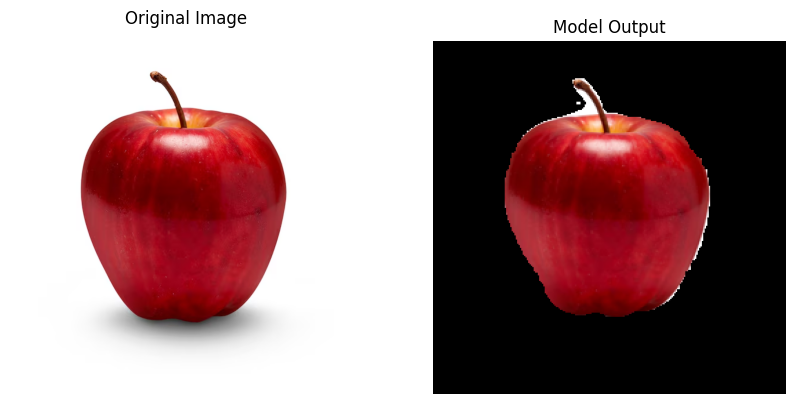

Inference completed. All outputs saved in 'outputs' folder.


In [14]:
# ===========================
# 1. Install required libraries
# ===========================
!pip install segmentation-models-pytorch --quiet
!pip install torch torchvision pillow numpy matplotlib --quiet

# ===========================
# 2. Import libraries
# ===========================
import torch
import segmentation_models_pytorch as smp
from PIL import Image
import torchvision.transforms as T
import numpy as np
from google.colab import files
import os
import matplotlib.pyplot as plt

# ===========================
# 3. Load the DeepLabV3+ model
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to your saved model in Drive
model_path = '/content/drive/MyDrive/infosys_ai_vision_extract/best_deeplab.pth'

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Model loaded successfully!")

# ===========================
# 4. Preprocessing & Postprocessing
# ===========================
def preprocess_image(image):
    transform = T.Compose([
        T.Resize((256, 256)),  # match your training size
        T.ToTensor(),
    ])
    return transform(image).unsqueeze(0)

def postprocess_mask(mask_tensor):
    mask = mask_tensor.squeeze().cpu().detach().numpy()
    mask = (mask > 0.5).astype(np.uint8) * 255
    return mask

# ===========================
# 5. Upload images manually
# ===========================
uploaded = files.upload()  # Opens file chooser in Colab

test_images = []
for file_name in uploaded.keys():
    img = Image.open(file_name).convert("RGB")
    test_images.append((file_name, img))

print(f"Total images uploaded: {len(test_images)}")

# ===========================
# 6. Run inference, visualize, and save outputs
# ===========================
os.makedirs("outputs", exist_ok=True)

for img_name, img in test_images:
    input_tensor = preprocess_image(img).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        mask = torch.sigmoid(output)

    mask_np = postprocess_mask(mask)

    # Overlay (extracted object)
    overlay = np.array(img.resize((256, 256))).copy()
    overlay[mask_np == 0] = [0, 0, 0]
    overlay_img = Image.fromarray(overlay)

    # Save overlay image
    output_path = os.path.join("outputs", os.path.basename(img_name))
    overlay_img.save(output_path)

    # ===========================
    # Visualization
    # ===========================
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Model Output")
    plt.imshow(overlay_img)
    plt.axis("off")

    plt.show()

print("Inference completed. All outputs saved in 'outputs' folder.")
